In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    r2_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    GroupKFold,
    LeaveOneGroupOut,
    train_test_split,
)
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler
from sklearn.svm import SVC
from tools import compute_PCA, compute_TSNE, load_data

In [2]:
X, F, T, A, P = load_data([ps for ps in range(1, 16)], z_score_norm=None)
X = X.reshape(X.shape[0], X.shape[1] * X.shape[1])

load: ['P01', 'P02', 'P03', 'P04', 'P05', 'P06', 'P07', 'P08', 'P09', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15']


$$F \rightarrow \mathrm{Force}$$
$$T \rightarrow \mathrm{Torque}$$
$$A \rightarrow \mathrm{Angle}$$

In [3]:
def indices_with_tolerance(arr, target, tol):
    """
    A ... angle/position or Force or Torque
    target ... target angle
    tol ... +/- tolerance
    """
    arr = np.asarray(arr)
    detected = np.where(np.abs(arr - target) <= tol)[0]
    print(f"Found {len(detected):,} for position {target} and a tolerance of {tol}.")
    return detected

## Mapping: $\mathbf{X} \rightarrow A|_{\mathrm{targets}}$

_Classification_

In [4]:
p1s = indices_with_tolerance(A, 25, tol=1)
p2s = indices_with_tolerance(A, 50, tol=1)
p3s = indices_with_tolerance(A, 75, tol=1)
# define targets
targets = np.concatenate([p1s, p2s, p3s])
y_label = [r"25$\pm$1°", r"50$\pm$1°", r"75$\pm$1°"]
np.random.shuffle(targets)

Found 1,049 for position 25 and a tolerance of 1.
Found 1,041 for position 50 and a tolerance of 1.
Found 1,052 for position 75 and a tolerance of 1.


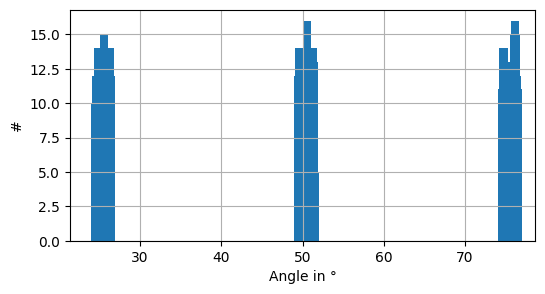

In [5]:
plt.figure(figsize=(6, 3))
plt.hist(A[targets], bins=len(targets), align="mid", width=1)
plt.grid()
plt.ylabel("#")
plt.xlabel("Angle in °")
plt.show()

**Train/Valid**

In [6]:
y = A[targets]  # A -> Angle

EIT = X[targets]
Pwise = P[targets]

y_cont = y.reshape(-1, 1)
binning = KBinsDiscretizer(
    n_bins=3,
    encode="ordinal",
    strategy="quantile",
    quantile_method="averaged_inverted_cdf",
)
y = binning.fit_transform(y_cont).ravel()

In [7]:
# Train Valid split
X_train, X_valid, y_train, y_valid = train_test_split(
    EIT, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_valid.shape, y_train.shape, y_valid.shape)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)

(2513, 256) (629, 256) (2513,) (629,)


In [8]:
param_grid = {
    "n_estimators": [10, 50, 100],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"],
}

# GridSearch
grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=50,
    verbose=1,
)
grid.fit(X_train, y_train)

print("Beste Parameter:", grid.best_params_)
print("Beste CV-Accuracy:", grid.best_score_)

Fitting 5 folds for each of 540 candidates, totalling 2700 fits
Beste Parameter: {'bootstrap': True, 'class_weight': None, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
Beste CV-Accuracy: 0.9610005306804592


In [9]:
rf_model = RandomForestClassifier(**grid.best_params_)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_valid)
accuracy_score(y_valid, y_pred)

0.9809220985691574


Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98       180
         1.0       0.97      0.98      0.97       210
         2.0       1.00      0.98      0.99       239

    accuracy                           0.98       629
   macro avg       0.98      0.98      0.98       629
weighted avg       0.98      0.98      0.98       629



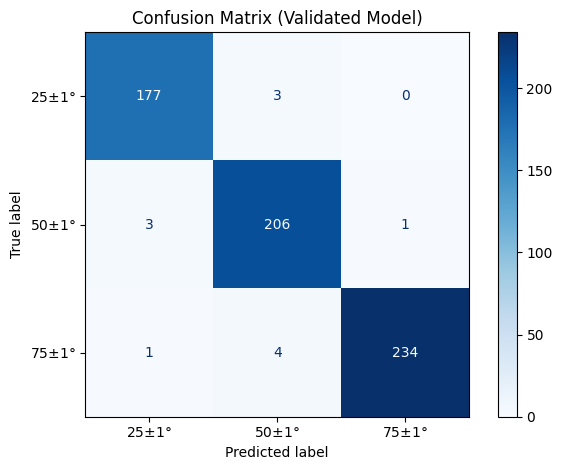

In [10]:
cm = confusion_matrix(y_valid, y_pred)
print("\nClassification Report:")
print(classification_report(y_valid, y_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix (Validated Model)")
plt.tight_layout()
plt.show()

**Train/Test** -> Participant wise

In [15]:
y = A[targets]  # A -> Angle
EIT = X[targets]
Pwise = P[targets]

y_cont = y.reshape(-1, 1)
binning = KBinsDiscretizer(
    n_bins=3,
    encode="ordinal",
    strategy="quantile",
    quantile_method="averaged_inverted_cdf",
)
y = binning.fit_transform(y_cont).ravel()

In [ ]:
param_grid = {
    "n_estimators": [10, 50, 100],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"],
}

cv = GroupKFold(n_splits=3)

grid = GridSearchCV(
    RandomForestClassifier(), param_grid, scoring="accuracy", cv=cv, n_jobs=50, verbose=1, refit=True
)

grid.fit(EIT, y, groups=Pwise)

print("\nBest parameter:")
print(grid.best_params_)

print("\nBest CV-accuracy:")
print(grid.best_score_)

Fitting 3 folds for each of 270 candidates, totalling 810 fits


In [ ]:
best_model = grid.best_estimator_
y_pred = best_model.predict(EIT)

acc = accuracy_score(y, y_pred)
cm = confusion_matrix(y, y_pred)

print("\nClassification Report:")
print(classification_report(y, y_pred))

print("Accuracy (total):", acc)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="Blues", values_format="d")

plt.title("Patient-wise Confusion Matrix (Cross-Validated Model)")
plt.tight_layout()
plt.show()

## Mapping: $\mathbf{X} \rightarrow T|_{\mathrm{targets}}$

In [ ]:
p1s = indices_with_tolerance(T, 50, tol=20)
p2s = indices_with_tolerance(T, 125, tol=20)
p3s = indices_with_tolerance(T, 200, tol=20)
# define targets
targets = np.concatenate([p1s, p2s, p3s])
y_label = [r"50$\pm$20Nm", r"125$\pm$20Nm", r"200$\pm$20Nm"]
np.random.shuffle(targets)

In [ ]:
plt.figure(figsize=(6, 3))
plt.hist(T[targets], bins=len(targets), align="mid", width=1)
plt.grid()
plt.ylabel("#")
plt.xlabel("Angle in Nm")
plt.show()

**Train/Valid**

In [ ]:
y = T[targets]  # T -> Torque

EIT = X[targets]
Pwise = P[targets]

y_cont = y.reshape(-1, 1)
binning = KBinsDiscretizer(
    n_bins=3,
    encode="ordinal",
    strategy="quantile",
    quantile_method="averaged_inverted_cdf",
)
y = binning.fit_transform(y_cont).ravel()

In [ ]:
# Train Valid split
X_train, X_valid, y_train, y_valid = train_test_split(
    EIT, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_valid.shape, y_train.shape, y_valid.shape)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)

In [ ]:
param_grid = {
    "n_estimators": [10, 50, 100],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"],
}

# GridSearch
grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=50,
    verbose=1,
)
grid.fit(X_train, y_train)

print("Beste Parameter:", grid.best_params_)
print("Beste CV-Accuracy:", grid.best_score_)

In [ ]:
rf_model = RandomForestClassifier(**grid.best_params_)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_valid)
accuracy_score(y_valid, y_pred)

In [ ]:
cm = confusion_matrix(y_valid, y_pred)
print("\nClassification Report:")
print(classification_report(y_valid, y_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix (Validated Model)")
plt.tight_layout()
plt.show()

**Train/Test** -> Participant wise

In [ ]:
y = T[targets]  # T -> Torque
EIT = X[targets]
Pwise = P[targets]

y_cont = y.reshape(-1, 1)
binning = KBinsDiscretizer(
    n_bins=3,
    encode="ordinal",
    strategy="quantile",
    quantile_method="averaged_inverted_cdf",
)
y = binning.fit_transform(y_cont).ravel()

In [ ]:
param_grid = {
    "n_estimators": [10, 50, 100],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"],
}

cv = GroupKFold(n_splits=5)

grid = GridSearchCV(
    RandomForestClassifier(), param_grid, scoring="accuracy", cv=cv, n_jobs=50, verbose=1, refit=True
)

grid.fit(EIT, y, groups=Pwise)

print("\nBest parameter:")
print(grid.best_params_)

print("\nBest CV-accuracy:")
print(grid.best_score_)

In [ ]:
best_model = grid.best_estimator_
y_pred = best_model.predict(EIT)

acc = accuracy_score(y, y_pred)
cm = confusion_matrix(y, y_pred)

print("\nClassification Report:")
print(classification_report(y, y_pred))

print("Accuracy (total):", acc)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_label)
disp.plot(cmap="Blues", values_format="d")

plt.title("Patient-wise Confusion Matrix (Cross-Validated Model)")
plt.tight_layout()
plt.show()

___

In [ ]:
# include this?
from sklearn.metrics import balanced_accuracy_score

y_true = [0, 1, 0, 0, 1, 0]
y_pred = [0, 1, 0, 0, 0, 1]
balanced_accuracy_score(y_true, y_pred)